In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [8]:
from pathlib import Path

data_path = Path("C:/Users/ASUS/Desktop/OELP project/data/processed/online_retail_cleaned_data.csv")

df = pd.read_csv(
    data_path,
    parse_dates=["InvoiceDate"]
)

In [9]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


## Recency

In [10]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)

Reference date: 2010-12-10 20:01:00


In [11]:
last_purchase = (
    df.groupby("Customer ID")["InvoiceDate"]
      .max()
)
last_purchase.head()

Customer ID
12346   2010-10-04 16:33:00
12347   2010-12-07 14:57:00
12348   2010-09-27 14:59:00
12349   2010-10-28 08:23:00
12351   2010-11-29 15:23:00
Name: InvoiceDate, dtype: datetime64[us]

In [12]:
recency = (
    reference_date - last_purchase
).dt.days

recency.head()

Customer ID
12346    67
12347     3
12348    74
12349    43
12351    11
Name: InvoiceDate, dtype: int64

In [13]:
recency.describe()

count    4383.000000
mean       91.395163
std        98.176493
min         1.000000
25%        17.000000
50%        52.000000
75%       138.000000
max       374.000000
Name: InvoiceDate, dtype: float64

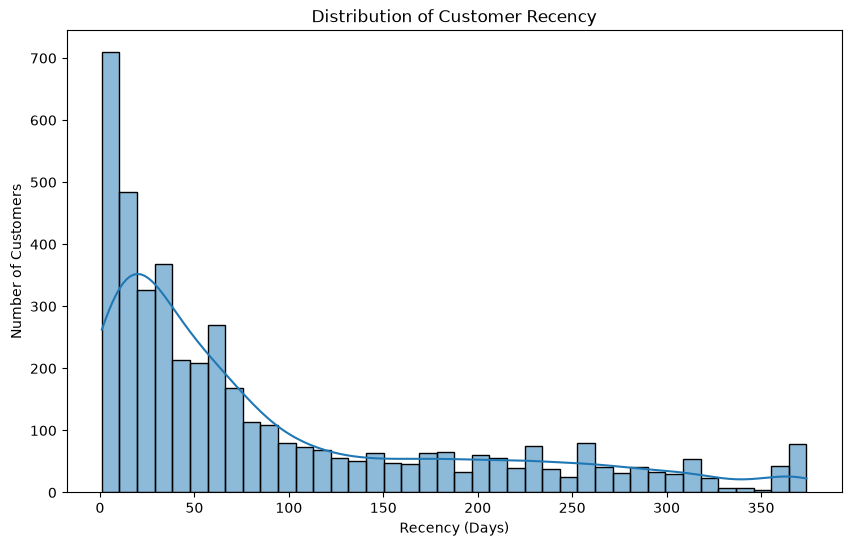

In [14]:
plt.figure(figsize=(10, 6))

sns.histplot(
    recency,
    bins=40,
    kde=True
)

plt.title("Distribution of Customer Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Customer recency is right-skewed, with a large concentration of
customers having relatively low recency values and a long tail of
customers with much longer periods since their last purchase.

The distribution extends across most of the observation period,
indicating substantial variation in customer activity.

No inactivity or churn threshold is defined at this stage; this will
be determined later using customer purchase behaviour and
inter-purchase intervals.

## Frequency

In [15]:
frequency = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
)

frequency.describe()

count    4383.000000
mean        5.381474
std        10.051921
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max       270.000000
Name: Invoice, dtype: float64

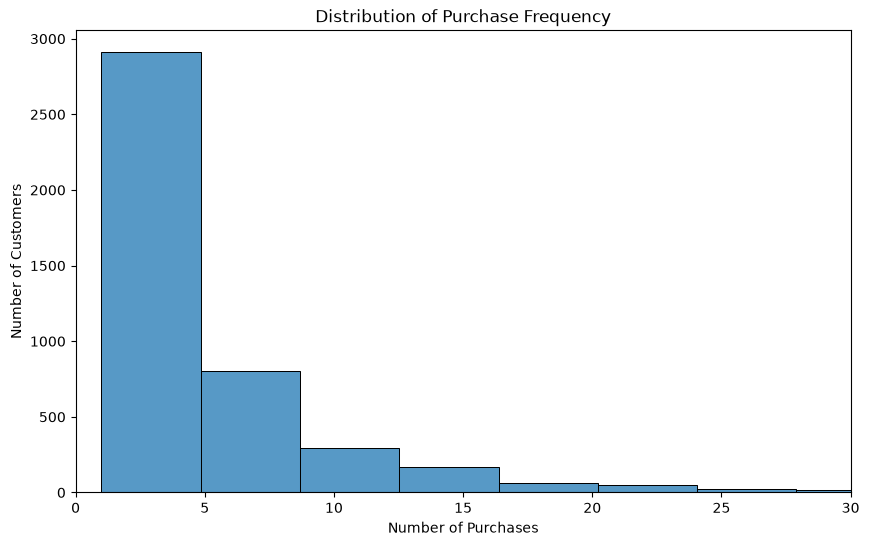

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    frequency,
    bins=70,
    kde=False
)

plt.title("Distribution of Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.xlim(0, 30)

plt.show()

### Observation

Purchase frequency is strongly right-skewed. Most customers make a
small number of purchases, while a smaller group makes purchases much
more frequently.

The long right tail indicates substantial variation in customer
purchase frequency. High-frequency customers are retained for further
analysis rather than being treated as errors at this stage.

## Monetary

In [17]:
monetary = (
    df.assign(Revenue=df["Quantity"] * df["Price"])
      .groupby("Customer ID")["Revenue"]
      .sum()
)

monetary.describe()

count      4383.000000
mean       1897.069492
std        8516.916415
min      -25111.090000
25%         282.885000
50%         652.450000
75%        1633.615000
max      341776.730000
Name: Revenue, dtype: float64

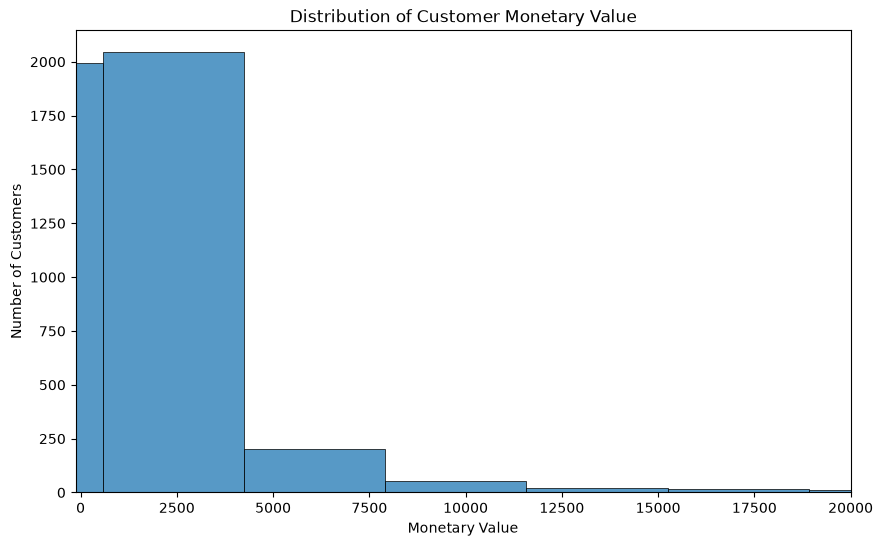

In [ ]:

plt.figure(figsize=(10, 6))

sns.histplot(
    monetary,
    bins=100,
    kde=False
)

plt.title("Distribution of Customer Monetary Value")
plt.xlabel("Monetary Value")
plt.ylabel("Number of Customers")

plt.xlim(
    monetary.quantile(0.01),
    monetary.quantile(0.99)
)

plt.xticks(range(0, 20001, 2500))

plt.show()

### Observation

Customer monetary value is strongly right-skewed. Most customers have
relatively low total spending, while a small number of customers have
much higher monetary values, creating a long right tail.

These high-value customers are retained because they may represent
genuine customer behaviour. Their effect on the feature distribution
will be considered later during transformation and clustering.

## Average Order Value

In [19]:
customer_features = pd.concat(
    [recency, frequency, monetary],
    axis=1
)

customer_features.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [20]:
customer_features["AOV"] = (
    customer_features["Monetary"] /
    customer_features["Frequency"]
)

customer_features.head()

,Recency,Frequency,Monetary,AOV
Customer ID,,,,
12346,67,15,-51.74,-3.449333
12347,3,2,1323.32,661.660000
12348,74,1,222.16,222.160000
12349,43,4,2646.99,661.747500
12351,11,1,300.93,300.930000


In [21]:
customer_features["AOV"].describe()

count     4383.000000
mean       287.882576
std        577.311786
min     -25111.090000
25%        147.052500
50%        227.347778
75%        350.637000
max      11880.840000
Name: AOV, dtype: float64

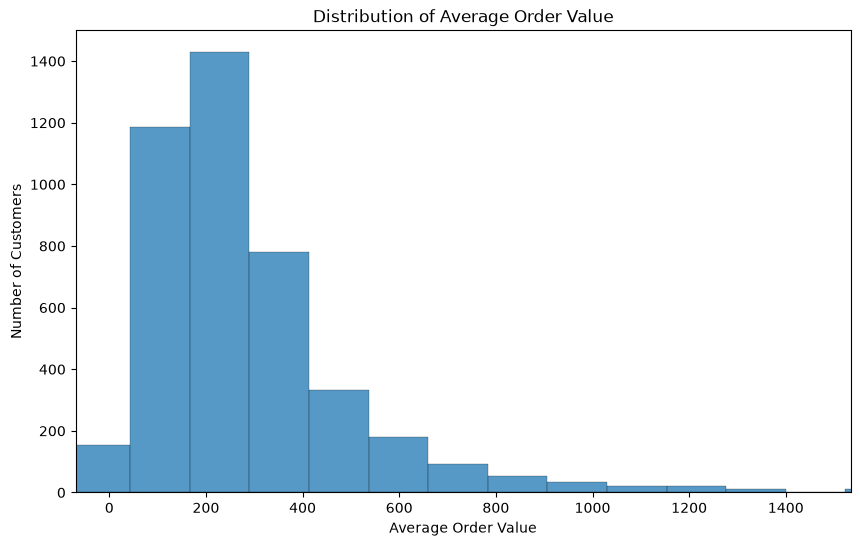

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    customer_features["AOV"],
    bins=300,
    kde=False
)

plt.title("Distribution of Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Number of Customers")

plt.xlim(
    customer_features["AOV"].quantile(0.01),
    customer_features["AOV"].quantile(0.99)
)

plt.show()

### Observation

Average Order Value is strongly right-skewed, with most customers having
relatively low average order values, concentrated mainly below 400.

A smaller group of customers has substantially higher average order
values, producing a long right tail extending beyond 1,000.

These high-AOV customers are retained because they may represent genuine
high-value purchasing behaviour. Their effect will be considered later
during feature transformation and clustering.

## Inter-Purchase Time

In [23]:
## Therefore, for a feature called Inter-Purchase Time, we should calculate the gaps using normal purchase invoices only, rather than treating a cancellation as another purchase event.
##  Similarly, our Frequency feature should ideally represent the number of actual purchase invoices, while return/cancellation behaviour can be captured separately later.

In [24]:
purchase_df = df[
    ~df["Invoice"].astype(str).str.startswith("C")
].copy()

In [25]:
customer_invoice_dates = (
    purchase_df[["Customer ID", "Invoice", "InvoiceDate"]]
    .drop_duplicates()
    .sort_values(["Customer ID", "InvoiceDate"])
)

In [26]:
customer_invoice_dates["InterPurchaseDays"] = (
    customer_invoice_dates
    .groupby("Customer ID")["InvoiceDate"]
    .diff()
    .dt.total_seconds() / (24 * 60 * 60)
)

In [27]:
customer_invoice_dates.head()

,Customer ID,Invoice,InvoiceDate,InterPurchaseDays
21447,12346,491725,2009-12-14 08:34:00,NaN
21702,12346,491742,2009-12-14 11:00:00,0.101389
21705,12346,491744,2009-12-14 11:02:00,0.001389
28492,12346,492718,2009-12-18 10:47:00,3.989583
28504,12346,492722,2009-12-18 10:55:00,0.005556


In [28]:
customer_invoice_dates["InterPurchaseDays"].describe()

count    14936.000000
mean        38.779514
std         51.311835
min          0.000000
25%          5.092882
50%         20.861111
75%         50.799479
max        363.888194
Name: InterPurchaseDays, dtype: float64

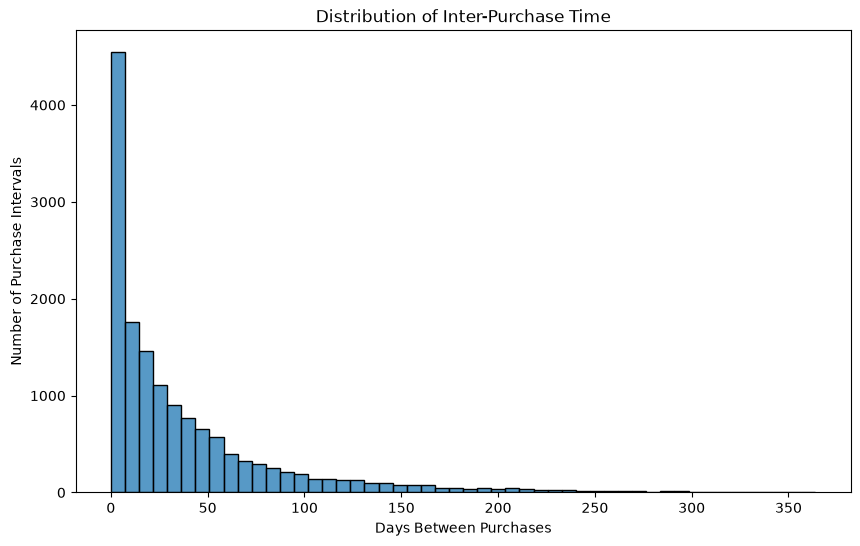

In [29]:
plt.figure(figsize=(10, 6))

sns.histplot(
    customer_invoice_dates["InterPurchaseDays"].dropna(),
    bins=50,
    kde=False
)

plt.title("Distribution of Inter-Purchase Time")
plt.xlabel("Days Between Purchases")
plt.ylabel("Number of Purchase Intervals")

plt.show()

### Observation

The inter-purchase time distribution is strongly right-skewed. Most
purchase intervals are relatively short, with the highest concentration
occurring within the first few days and weeks.

The frequency of purchase intervals decreases as the gap increases,
while a smaller number of intervals extend to several hundred days.

This indicates substantial variation in customer purchasing cycles, so a
single arbitrary inactivity threshold should not be assumed from the
distribution alone.

In [30]:
median_interpurchase = (
    customer_invoice_dates
    .groupby("Customer ID")["InterPurchaseDays"]
    .median()
)

median_interpurchase.describe()

count    2897.000000
mean       65.587127
std        64.085360
min         0.000694
25%        21.018056
50%        44.535417
75%        88.036806
max       361.841667
Name: InterPurchaseDays, dtype: float64

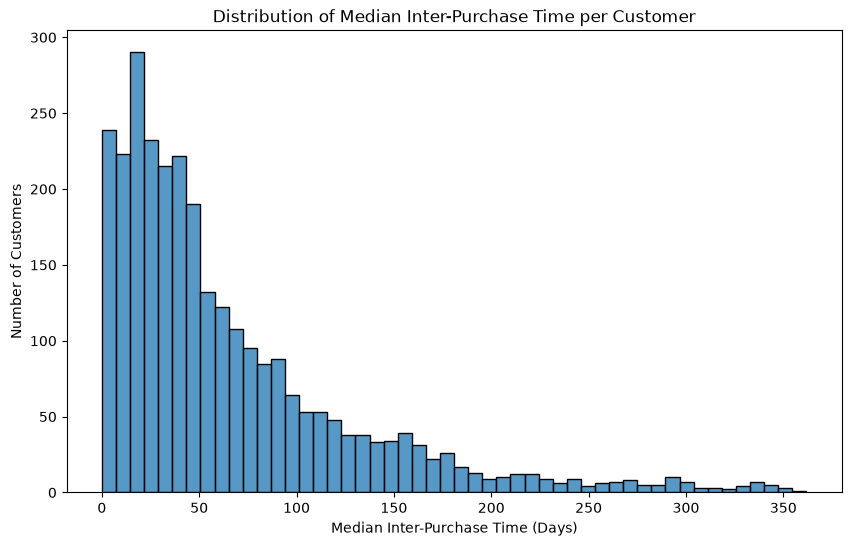

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(
    median_interpurchase.dropna(),
    bins=50,
    kde=False
)

plt.title("Distribution of Median Inter-Purchase Time per Customer")
plt.xlabel("Median Inter-Purchase Time (Days)")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Median inter-purchase time is right-skewed. Most customers have a
typical purchase interval below approximately 50 days, while the
number of customers decreases as the interval becomes longer.

A smaller group of customers has much longer typical purchase
intervals, extending to several hundred days. This indicates
substantial variation in customer purchasing cycles.

The feature will be retained for further customer segmentation and
retention analysis. No values are removed at this stage.

In [32]:
customer_features["Median_InterPurchase_Days"] = median_interpurchase

## Return / Cancellation Behaviour

In [33]:
cancellation_count = (
    df[df["Invoice"].astype(str).str.startswith("C")]
    .groupby("Customer ID")["Invoice"]
    .nunique()
)

In [34]:
total_invoice_count = (
    df.groupby("Customer ID")["Invoice"]
    .nunique()
)

In [35]:
return_rate = (
    cancellation_count
    .reindex(total_invoice_count.index, fill_value=0)
    / total_invoice_count
)

In [36]:
return_rate.describe()

count    4383.000000
mean        0.135882
std         0.205954
min         0.000000
25%         0.000000
50%         0.000000
75%         0.250000
max         1.000000
Name: Invoice, dtype: float64

The mean is about 13.6%, while the median is 0%. This indicates that a smaller group of customers has noticeably higher cancellation activity and pulls the average upward.
This means all of the invoices associated with those customers are C invoices. These customers should not automatically be considered errors; they may represent customers whose recorded activity consists entirely of cancellation/return transactions.

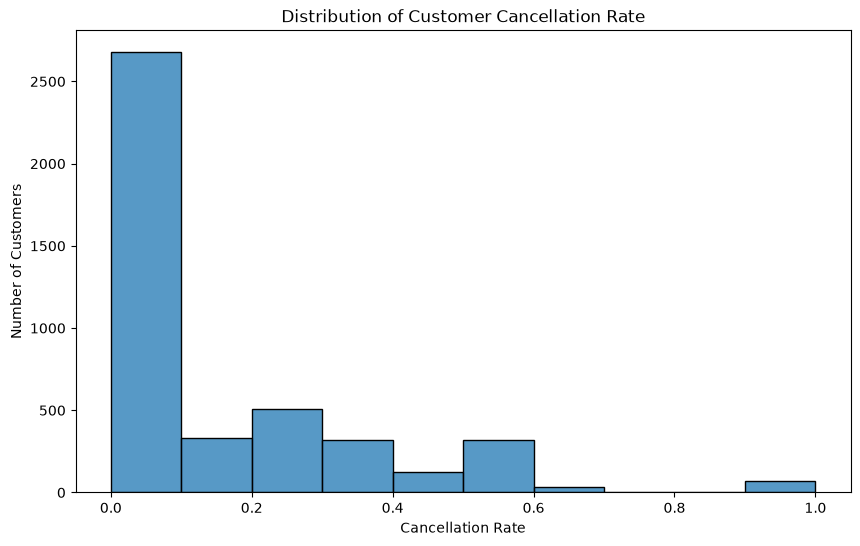

In [37]:
plt.figure(figsize=(10, 6))

sns.histplot(
    return_rate,
    bins=10,
    kde=False
)

plt.title("Distribution of Customer Cancellation Rate")
plt.xlabel("Cancellation Rate")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Customer cancellation rate is highly concentrated at zero. Most customers
have no cancellation invoices, while a smaller group shows cancellation
rates ranging from approximately 10% to 60%.

A very small number of customers have cancellation rates close to 100%.
Overall, cancellation behaviour varies considerably across customers,
with a strong concentration of customers having no cancellation activity.

The feature will be retained as a behavioural feature for customer
segmentation and retention analysis.

In [38]:
return_rate.name="Cancellation_Rate"
customer_features = customer_features.join(return_rate)
customer_features.head()

,Recency,Frequency,Monetary,AOV,Median_InterPurchase_Days,Cancellation_Rate
Customer ID,,,,,,
12346,67,15,-51.74,-3.449333,5.987847,0.266667
12347,3,2,1323.32,661.660000,37.025694,0.000000
12348,74,1,222.16,222.160000,NaN,0.000000
12349,43,4,2646.99,661.747500,90.896875,0.250000
12351,11,1,300.93,300.930000,NaN,0.000000


# 2. Customer Feature Validation

### 2.1 Feature Table Overview

In [39]:
customer_features.info()

<class 'pandas.DataFrame'>
Index: 4383 entries, 12346 to 18287
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Recency                    4383 non-null   int64  
 1   Frequency                  4383 non-null   int64  
 2   Monetary                   4383 non-null   float64
 3   AOV                        4383 non-null   float64
 4   Median_InterPurchase_Days  2897 non-null   float64
 5   Cancellation_Rate          4383 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 239.7 KB


In [40]:
customer_features.describe()

,Recency,Frequency,Monetary,AOV,Median_InterPurchase_Days,Cancellation_Rate
count,4383.000000,4383.000000,4383.000000,4383.000000,2897.000000,4383.000000
mean,91.395163,5.381474,1897.069492,287.882576,65.587127,0.135882
std,98.176493,10.051921,8516.916415,577.311786,64.085360,0.205954
min,1.000000,1.000000,-25111.090000,-25111.090000,0.000694,0.000000
25%,17.000000,1.000000,282.885000,147.052500,21.018056,0.000000
50%,52.000000,3.000000,652.450000,227.347778,44.535417,0.000000
75%,138.000000,6.000000,1633.615000,350.637000,88.036806,0.250000
max,374.000000,270.000000,341776.730000,11880.840000,361.841667,1.000000


In [41]:
customer_features.isna().sum()

Recency                         0
Frequency                       0
Monetary                        0
AOV                             0
Median_InterPurchase_Days    1486
Cancellation_Rate               0
dtype: int64

### Observation

Recency contains 69 missing values because these customers do not have
a normal purchase transaction from which their last purchase date can
be determined.

Median Inter-Purchase Time contains 1,486 missing values because these
customers do not have sufficient normal purchase history to calculate
a purchase interval, typically due to having only one purchase.

The remaining customer-level features contain no missing values.

These missing values will not be imputed at this stage because they have
a meaningful interpretation related to customer purchase history.

### 2.2 Correlation Analysis

In [44]:
correlation_matrix = customer_features.corr()

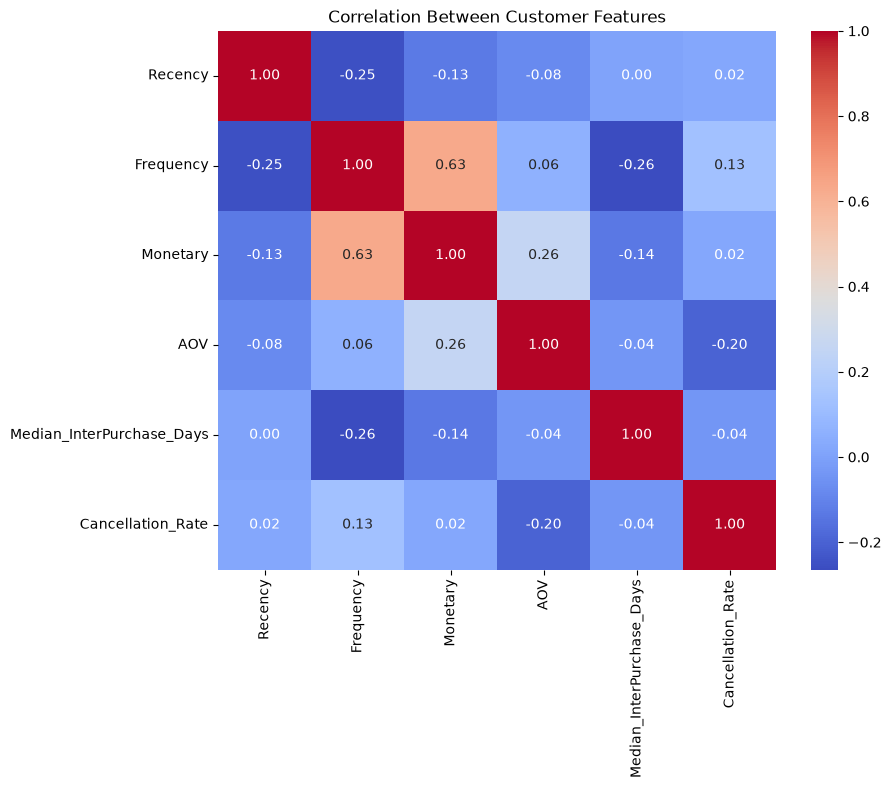

In [45]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Customer Features")
plt.show()

### Observation

The correlation analysis shows that most customer features have weak
linear relationships, indicating that they capture different aspects
of customer behaviour.

Frequency and Monetary show the strongest relationship with a
correlation of 0.63, indicating that customers with more purchases
generally generate higher total monetary value.

Frequency also has weak negative relationships with Recency (-0.25)
and Median Inter-Purchase Time (-0.26), suggesting that more frequent
customers tend to have more recent activity and shorter purchasing
intervals.

No feature is removed based on correlation alone at this stage.

## 3. Feature Transformation

### 3.1 Skewness Analysis

In [ ]:
skewness = customer_features.skew()
skewness.sort_values(ascending=False)

Monetary                     24.705589
Frequency                    10.586492
Median_InterPurchase_Days     1.808614
Cancellation_Rate             1.771071
Recency                       1.274995
AOV                         -15.866906
dtype: float64

### Observation

The skewness analysis shows that the customer-level features are not
normally distributed.

Monetary (24.71) and Frequency (10.59) are highly right-skewed, while
Median Inter-Purchase Time (1.81), Cancellation Rate (1.77), and
Recency (1.27) show moderate right skewness.

AOV has a strong negative skewness value (-15.87). This is influenced
by customers with negative net revenue caused by retained
cancellation-related transactions.

Because the features have substantially different distributions,
appropriate transformations will be considered before scaling and
clustering.

### Monetary Transformation

In [57]:
from sklearn.preprocessing import PowerTransformer

In [56]:
%pip install -U scikit-learn

  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl (8.4 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
    --------------------------------------- 0.8/37.4 MB 2.8 MB/s eta 0:00:13
   - -------------------------------------- 1.3/37.4 MB 2.9 MB/s eta 0:00:13
   - -------------------------------------- 1.6/37.4 MB 2.7 MB

In [58]:
pt_monetary=PowerTransformer(method='yeo-johnson')
monetary_transformed=pt_monetary.fit_transform(customer_features[["Monetary"]])
customer_features["Monetary_Transformed"] = (monetary_transformed.flatten())

In [69]:
customer_features["Monetary_Transformed"].skew()

np.float64(9.066851073727149)

In [71]:
customer_features["Monetary_Transformed"].describe()

count    4.383000e+03
mean    -2.269587e-17
std      1.000114e+00
min     -2.673280e+01
25%     -2.077335e-01
50%     -1.417374e-01
75%      1.635554e-02
max      3.175784e+01
Name: Monetary_Transformed, dtype: float64

### Observation

The extreme Monetary values were investigated and found to represent
genuine high-value customer behaviour rather than erroneous transactions.

Therefore, these customers were retained and no customer-level records
were removed based on high Monetary values.

Yeo-Johnson transformation reduced the Monetary skewness from 24.71 to
9.07, but substantial skewness remains. The transformed feature will be
evaluated later during final feature preparation rather than making a
premature transformation decision.

### Frequency Transformation

In [76]:
customer_features["Frequency"].describe()

count    4383.000000
mean        5.381474
std        10.051921
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max       270.000000
Name: Frequency, dtype: float64

In [77]:
frequency_log=np.log1p(customer_features["Frequency"])

In [78]:
frequency_log.skew()

np.float64(1.0216502846684299)

In [82]:
customer_features["Frequency_Transformed"] = frequency_log

### Observation

Frequency showed strong right skewness with a skewness value of 10.59.
A log1p transformation was applied because Frequency is a positive
count-based feature.

The transformation substantially reduced the skewness to approximately
1, indicating a much more balanced distribution and reducing the
influence of highly frequent customers.

The original Frequency feature is retained, while the transformed
version will be considered during final feature preparation.

### Recency Transformation

In [91]:
customer_features["Recency"].describe()

count    4383.000000
mean       91.395163
std        98.176493
min         1.000000
25%        17.000000
50%        52.000000
75%       138.000000
max       374.000000
Name: Recency, dtype: float64

In [94]:
from sklearn.preprocessing import PowerTransformer

pt_recency = PowerTransformer(method="yeo-johnson")

recency_transformed = pt_recency.fit_transform(
    customer_features[["Recency"]]
)

customer_features["Recency_Transformed"] = (
    recency_transformed.flatten()
)

In [95]:
customer_features["Recency_Transformed"].skew()

np.float64(-0.05826956035165745)

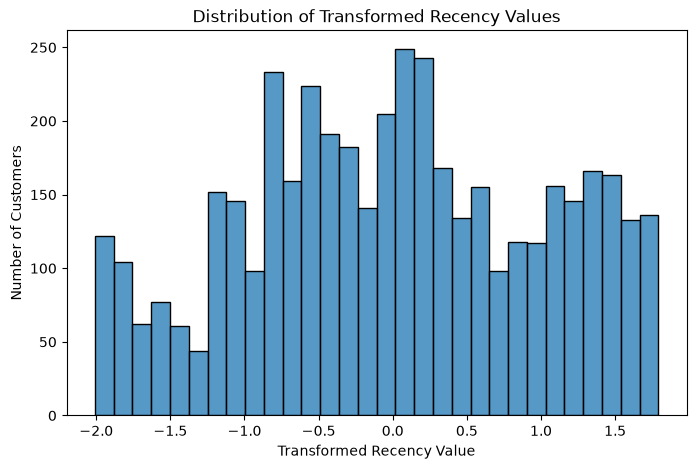

In [93]:
plt.figure(figsize=(8, 5))

sns.histplot(
    customer_features["Recency_Transformed"],
    bins=30,
    kde=False
)

plt.xlabel("Transformed Recency Value")
plt.ylabel("Number of Customers")
plt.title("Distribution of Transformed Recency Values")
plt.show()

### Observation

Recency showed moderate right skewness with an original skewness value
of 1.27.

A Yeo-Johnson transformation was applied to reduce the skewness while
preserving all customer records. The transformed feature had a
skewness of approximately -0.06, indicating that the distribution
became substantially more balanced.

The Yeo-Johnson transformed Recency feature will therefore be considered
for the final clustering feature set.

### Median Inter-Purchase Time Transformation

In [96]:
pt_interpurchase = PowerTransformer(method="yeo-johnson")

interpurchase_values = customer_features[
    ["Median_InterPurchase_Days"]
].dropna()

interpurchase_transformed = pt_interpurchase.fit_transform(
    interpurchase_values
)


In [97]:
pd.Series(
    interpurchase_transformed.flatten()
).skew()

np.float64(-0.013244158676884716)

In [98]:
interpurchase_transformed = pd.Series(
    interpurchase_transformed.flatten(),
    index=interpurchase_values.index
)

customer_features["Median_InterPurchase_Transformed"] = (
    interpurchase_transformed
)

In [99]:
customer_features.head()

,Recency,Frequency,Monetary,AOV,Median_InterPurchase_Days,Cancellation_Rate,Monetary_Transformed,Frequency_Transformed,Recency_Transformed,Median_InterPurchase_Transformed
Customer ID,,,,,,,,,,
12346,67,15,-51.74,-3.449333,5.987847,0.266667,-0.294749,2.772589,0.203877,-1.420592
12347,3,2,1323.32,661.660000,37.025694,0.000000,-0.031979,1.098612,-1.663807,-0.204136
12348,74,1,222.16,222.160000,NaN,0.000000,-0.219341,0.693147,0.284168,NaN
12349,43,4,2646.99,661.747500,90.896875,0.250000,0.167733,1.609438,-0.138569,0.693536
12351,11,1,300.93,300.930000,NaN,0.000000,-0.204342,0.693147,-1.034301,NaN


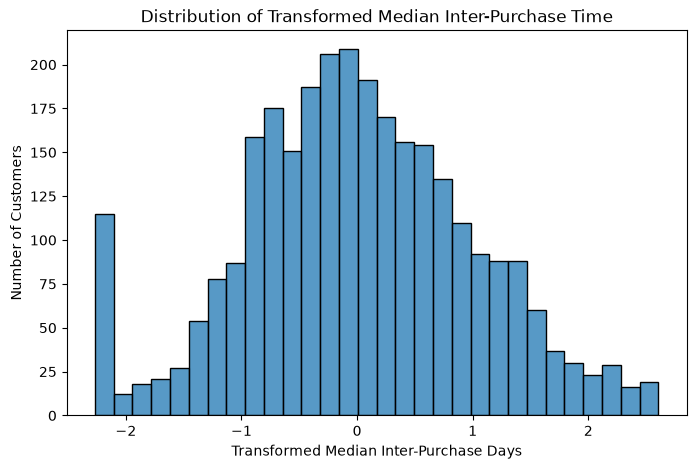

In [100]:
plt.figure(figsize=(8, 5))

sns.histplot(
    customer_features["Median_InterPurchase_Transformed"],
    bins=30,
    kde=False
)

plt.xlabel("Transformed Median Inter-Purchase Days")
plt.ylabel("Number of Customers")
plt.title("Distribution of Transformed Median Inter-Purchase Time")
plt.show()

### Observation

Median Inter-Purchase Time showed right skewness with a skewness value
of 1.81.

The Yeo-Johnson transformation substantially reduced the skewness to
approximately -0.01, resulting in a nearly symmetric distribution.

The original missing values were preserved because customers without
sufficient purchase history cannot have a meaningful inter-purchase
interval.

The transformed feature will therefore be considered for the final
clustering feature set.

## Final Feature Selection for Clustering

In [105]:
clustering_features = customer_features[
    [
        "Recency_Transformed",
        "Frequency_Transformed",
        "Monetary_Transformed",
        "AOV",
        "Median_InterPurchase_Transformed",
        "Cancellation_Rate"
    ]
].copy()

In [106]:
clustering_features.head()

,Recency_Transformed,Frequency_Transformed,Monetary_Transformed,AOV,Median_InterPurchase_Transformed,Cancellation_Rate
Customer ID,,,,,,
12346,0.203877,2.772589,-0.294749,-3.449333,-1.420592,0.266667
12347,-1.663807,1.098612,-0.031979,661.660000,-0.204136,0.000000
12348,0.284168,0.693147,-0.219341,222.160000,NaN,0.000000
12349,-0.138569,1.609438,0.167733,661.747500,0.693536,0.250000
12351,-1.034301,0.693147,-0.204342,300.930000,NaN,0.000000


In [107]:
clustering_features.isna().sum()

Recency_Transformed                    0
Frequency_Transformed                  0
Monetary_Transformed                   0
AOV                                    0
Median_InterPurchase_Transformed    1486
Cancellation_Rate                      0
dtype: int64